Bootcamp Capstone Project
Objective
The goal of this project is to analyze patient demographic and medical data to identify key risk factors associated with stroke. Stroke is a major cause of death and long-term disability. Early prediction can help healthcare providers intervene before severe outcomes occur.

This project includes:

Data Cleaning
Exploratory Data Analysis (EDA)
5–7 Visualizations
Modeling
Insights Summary

In [78]:
# Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [79]:
df_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [80]:
df_data.size

61320

In [81]:
df_data.info

<bound method DataFrame.info of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban 

In [82]:
df_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


    Clean the dataset

Make a copy of the DS

Standardize column names

Remove 'id' column 

Handle missing values Remove duplicates

Basic validity checks

In [83]:
df=df_data.copy()



In [84]:
df.duplicated().sum()


np.int64(0)

In [85]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ", "_")

In [86]:
#df.drop(columns=["id"], inplace=True)


In [87]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [88]:
df.isna().sum().sort_values(ascending=False)

bmi                  201
id                     0
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

Handling Missing BMI Values

BMI is always a positive measurement, so missing values cannot represent an actual physical state.

Using the median avoids unrealistic or impossible values.

The median is stable and not influenced by extreme BMI outliers.

In [89]:
df["bmi"]=df["bmi"].fillna(df["bmi"].median())

In [90]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [91]:
#validity check
#Age should be above 0
#bmi should be positive
#glucose should be positive
df = df[(df["age"] > 0) & (df["bmi"] > 0) & (df["avg_glucose_level"] > 0)]
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [92]:
#Project Requirement: Univariate Analysis 

C:\Users\mrmik\AppData\Local\Temp\ipykernel_41084\1234419327.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="bmi_category", palette="Set3")


Text(0, 0.5, 'Count')

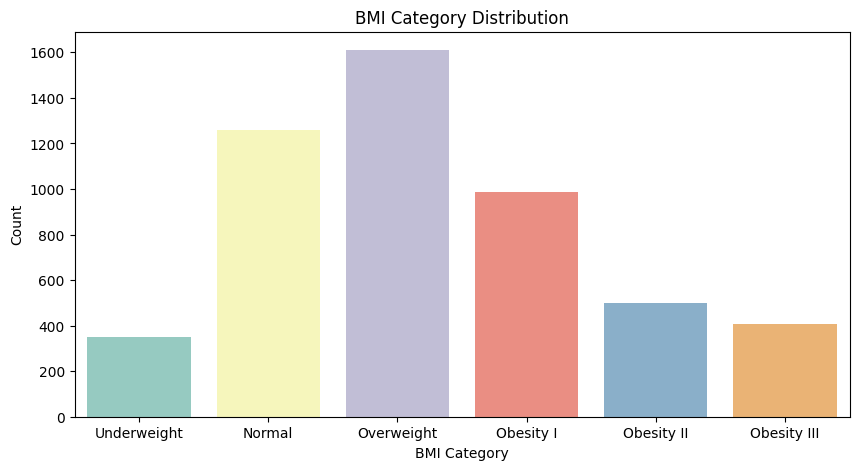

In [94]:
bins = [0, 18.5, 25, 30, 35, 40, 100] 
labels = ["Underweight", "Normal", "Overweight", "Obesity I", "Obesity II", "Obesity III"]
df["bmi_category"] = pd.cut(df["bmi"], bins=bins, labels=labels) 
plt.figure(figsize=(10,5)) 
sns.countplot(data=df, x="bmi_category", palette="Set3") 
plt.title("BMI Category Distribution") 
plt.xlabel("BMI Category") 
plt.ylabel("Count")

Text(0, 0.5, 'Count')

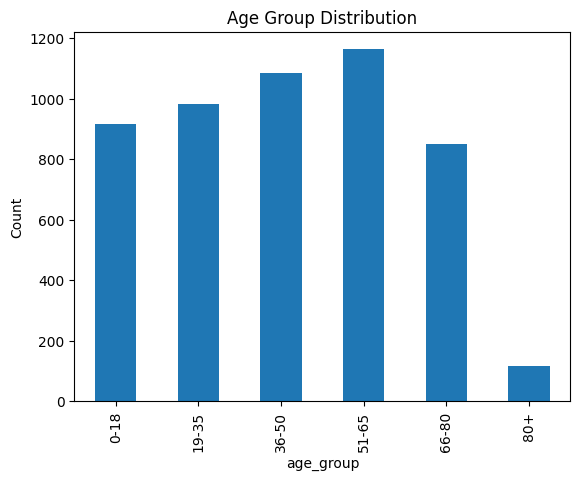

In [95]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 80, 100], labels=['0-18', '19-35', '36-50', '51-65', '66-80', '80+']) 
df['age_group'].value_counts().sort_index().plot(kind='bar')
plt.title("Age Group Distribution") 
plt.ylabel("Count")

([0, 1, 2, 3],
 [Text(0, 0, 'formerly smoked'),
  Text(1, 0, 'never smoked'),
  Text(2, 0, 'smokes'),
  Text(3, 0, 'Unknown')])

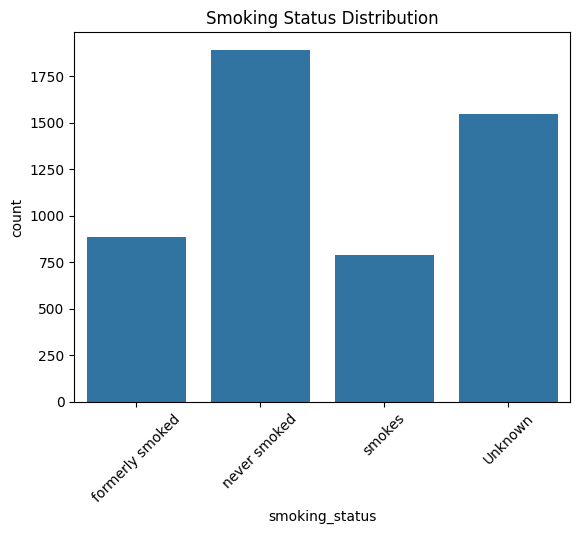

In [96]:
sns.countplot(data=df, x="smoking_status") 
plt.title("Smoking Status Distribution") 
plt.xticks(rotation=45)

 BIVARIATE ANALYSIS (8 Visuals)

Text(0.5, 1.0, 'Age Distribution by Stroke')

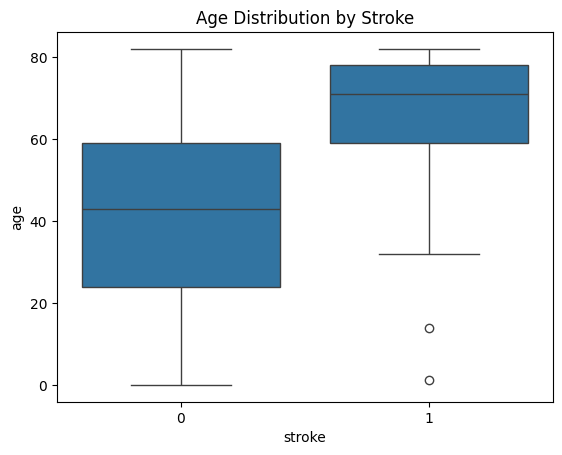

In [97]:
sns.boxplot(x="stroke", y="age", data=df) 
plt.title("Age Distribution by Stroke")


1. The first plot is a histogram + KDE density lines new one 
This plot shows the distribution of ages for stroke vs. non‑stroke groups.

Bars = how many people fall into each age range

Two colors = stroke vs. no stroke

Smooth lines = KDE curves (density estimates)

2. The second plot is a stacked bar chart + frequency lines
This plot shows counts of stroke vs. non‑stroke at each exact age.

Bars = number of people at each age

Stacked colors = stroke vs. no stroke

Lines = count trend across ages

This plot answers:
“How does age distribute for stroke vs. non‑stroke individuals?”

It focuses on shape, spread, and where the stroke cases cluster.

The lines are KDE density curves.

They show the probability distribution of age for each group.

The red line shows where stroke cases are concentrated.

The pink line shows where non‑stroke cases are concentrated.

KDE smooths the distribution so you can see the overall pattern, not just the bars.

Text(0.5, 1.0, 'Age Distribution by Stroke Outcome')

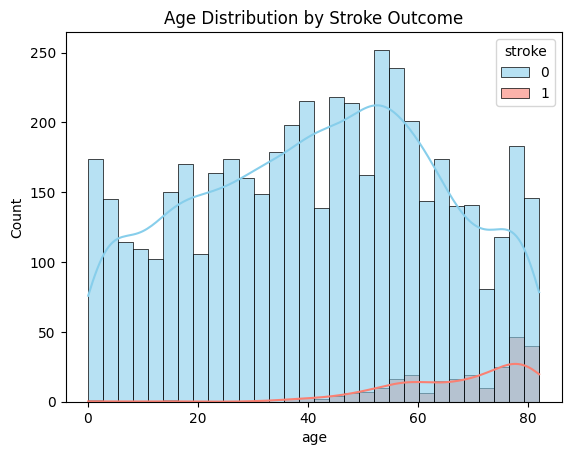

In [98]:
plt.figure() 
sns.histplot(data=df, x="age", hue="stroke", bins=30, kde=True, palette={0: "skyblue", 1: "salmon"}, alpha=0.6, edgecolor='black', linewidth=0.5) 
plt.title("Age Distribution by Stroke Outcome")

Text(0, 0.5, 'Stroke Probability')

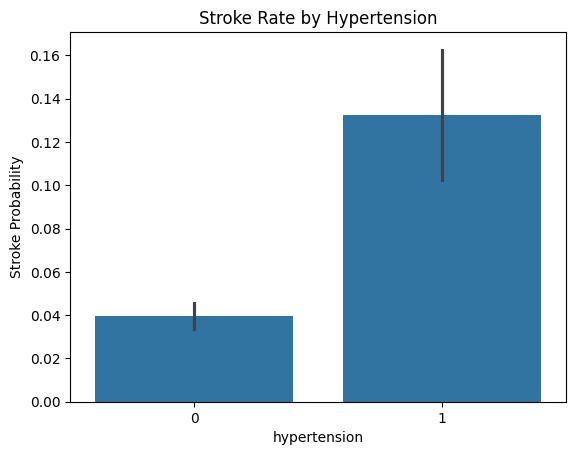

In [99]:
sns.barplot(x="hypertension", y="stroke", data=df) 
plt.title("Stroke Rate by Hypertension") 
plt.ylabel("Stroke Probability")

Text(0, 0.5, 'Stroke Probability')

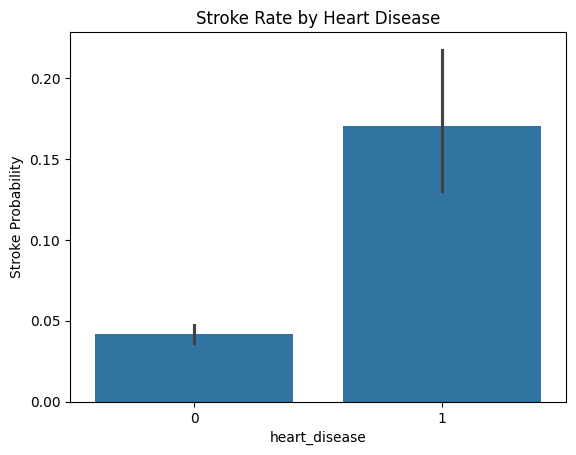

In [100]:
sns.barplot(x="heart_disease", y="stroke", data=df)
plt.title("Stroke Rate by Heart Disease") 
plt.ylabel("Stroke Probability")

Text(0.5, 1.0, 'Average Glucose Level by Stroke')

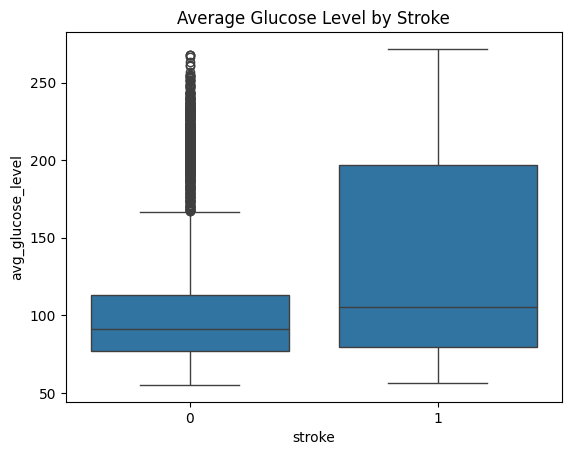

In [101]:
sns.boxplot(x="stroke", y="avg_glucose_level", data=df) 
plt.title("Average Glucose Level by Stroke")

Text(0.5, 1.0, 'BMI Distribution by Stroke')

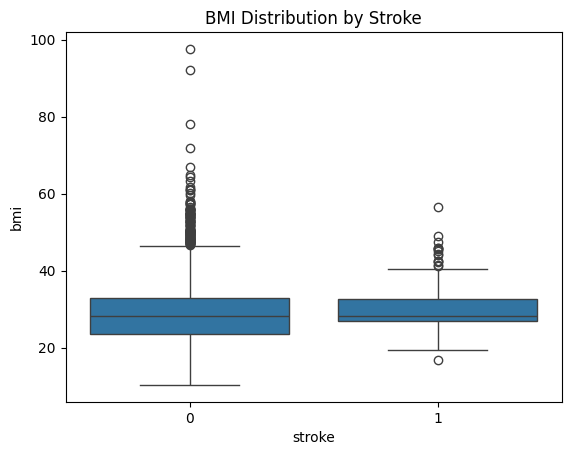

In [102]:
sns.boxplot(x="stroke", y="bmi", data=df) 
plt.title("BMI Distribution by Stroke")

Text(0, 0.5, 'Stroke Probability')

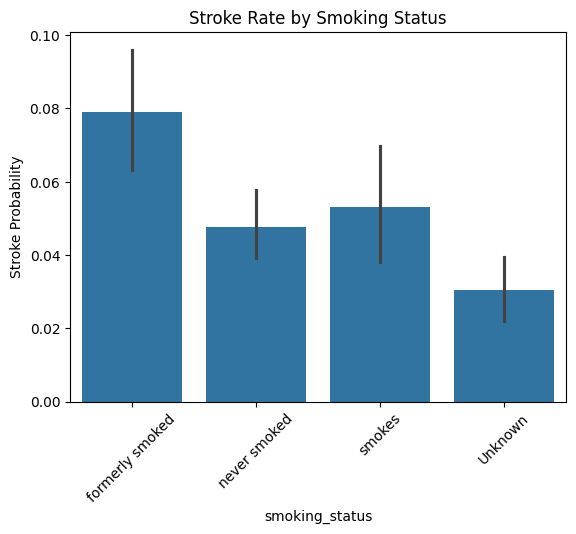

In [103]:
sns.barplot(x="smoking_status", y="stroke", data=df) 
plt.xticks(rotation=45) 
plt.title("Stroke Rate by Smoking Status") 
plt.ylabel("Stroke Probability")


C:\Users\mrmik\AppData\Local\Temp\ipykernel_41084\600846452.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_stroke = df.groupby('bmi_category')['stroke'].mean() * 100


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Underweight'),
  Text(1, 0, 'Normal'),
  Text(2, 0, 'Overweight'),
  Text(3, 0, 'Obesity I'),
  Text(4, 0, 'Obesity II'),
  Text(5, 0, 'Obesity III')])

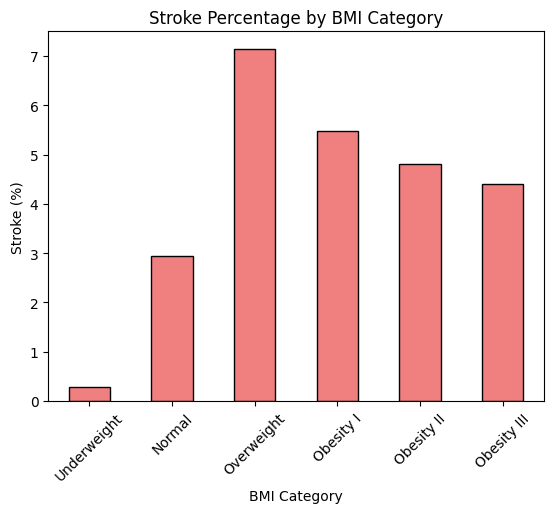

In [104]:
bmi_stroke = df.groupby('bmi_category')['stroke'].mean() * 100 
bmi_stroke.plot(kind='bar', color='lightcoral', edgecolor='black') 
plt.title('Stroke Percentage by BMI Category') 
plt.xlabel('BMI Category') 
plt.ylabel('Stroke (%)') 
plt.xticks(rotation=45)

MULTIVARIATE ANALYSIS 



Text(0, 0.5, 'Age')

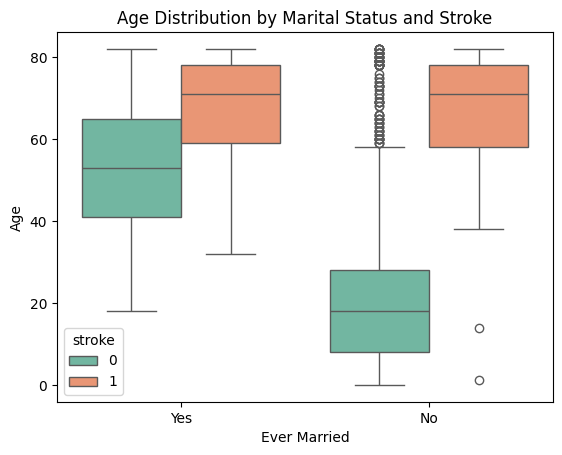

In [105]:
sns.boxplot(data=df, x="ever_married", y="age", hue="stroke", palette="Set2") 
plt.title("Age Distribution by Marital Status and Stroke") 
plt.xlabel("Ever Married") 
plt.ylabel("Age")

 CORRELATION ANALYSIS (2 Visuals)

Text(0.5, 1.0, 'Correlation Between Strong Predictors and Stroke')

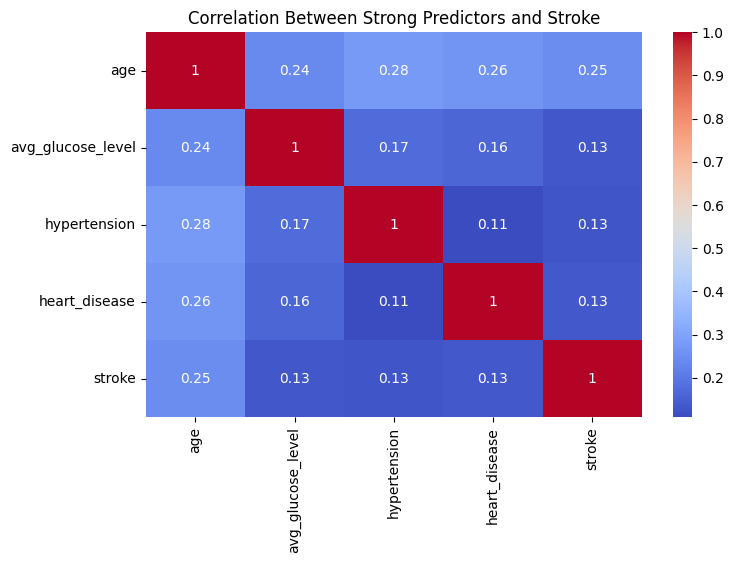

In [106]:
strong_correlation = ["age", "avg_glucose_level", "hypertension", "heart_disease", "stroke"] 
plt.figure(figsize=(8,5)) 
sns.heatmap(df[strong_correlation].corr(), cmap="coolwarm", annot=True) 
plt.title("Correlation Between Strong Predictors and Stroke")

These visualizations explore deeper relationships between stroke and demographic/medical variables.

C:\Users\mrmik\AppData\Local\Temp\ipykernel_41084\995495248.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_glucose = smoker_df.groupby('age_group')[['avg_glucose_level', 'stroke']].mean()


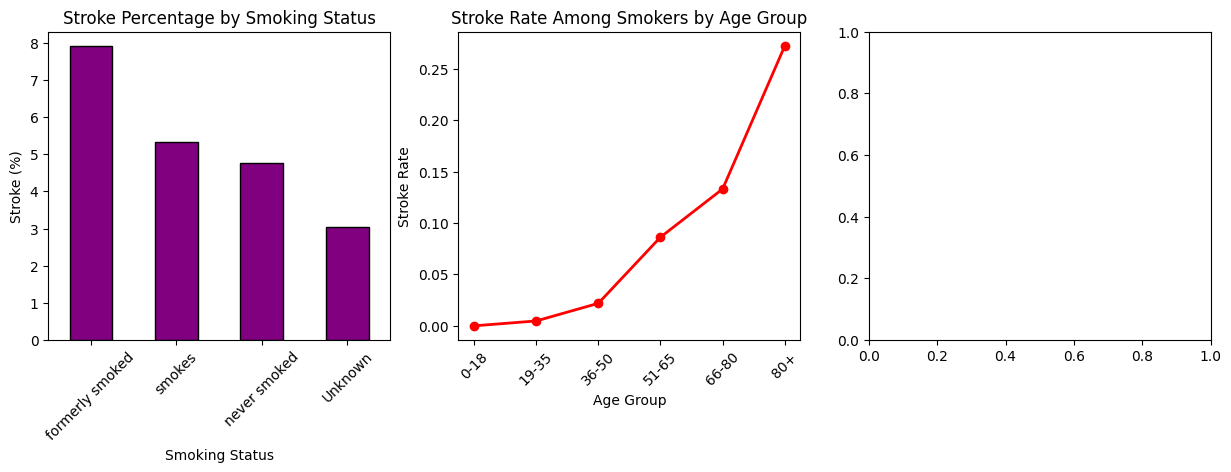

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smoking_stroke = df.groupby('smoking_status')['stroke'].mean() * 100
smoking_stroke = smoking_stroke.sort_values(ascending=False)
smoking_stroke.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')

axes[0].set_title('Stroke Percentage by Smoking Status')
axes[0].set_xlabel('Smoking Status')
axes[0].set_ylabel('Stroke (%)')
axes[0].tick_params(axis='x', rotation=45)

smoker_df = df[df['smoking_status'] == 'smokes']
age_glucose = smoker_df.groupby('age_group')[['avg_glucose_level', 'stroke']].mean()
age_glucose['stroke'].plot(kind='line', marker='o', ax=axes[1], color='red', linewidth=2)

axes[1].set_title('Stroke Rate Among Smokers by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Stroke Rate')
axes[1].tick_params(axis='x', rotation=45)

C:\Users\mrmik\AppData\Local\Temp\ipykernel_41084\1058568731.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_stroke = df.groupby('bmi_category')['stroke'].mean() * 100


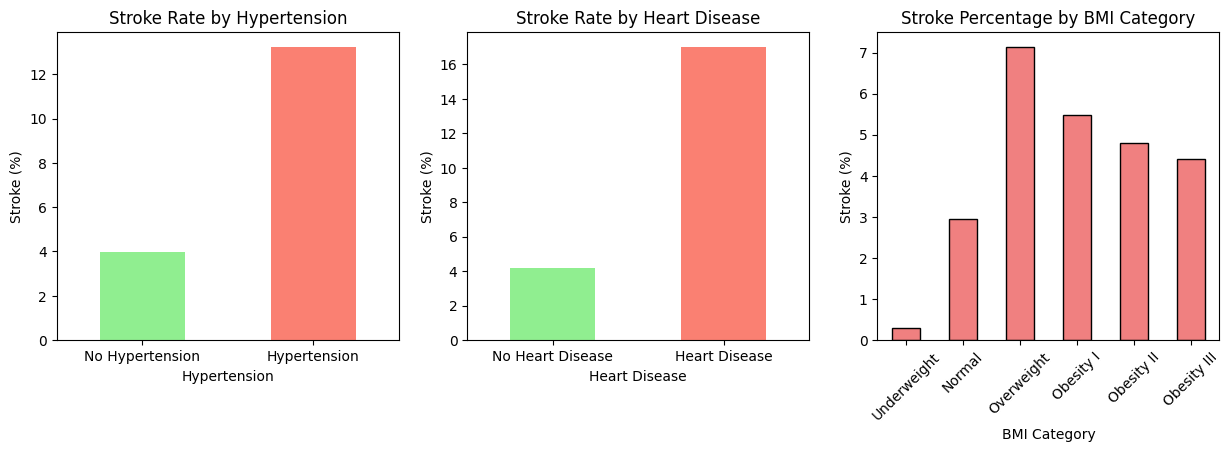

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hypertension_stroke = pd.crosstab(df['hypertension'], df['stroke'], normalize='index') * 100
hypertension_stroke[1].plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'])
axes[0].set_title('Stroke Rate by Hypertension')
axes[0].set_xlabel('Hypertension')
axes[0].set_ylabel('Stroke (%)')
axes[0].set_xticklabels(['No Hypertension', 'Hypertension'], rotation=0)

# Heart disease and stroke
heart_stroke = pd.crosstab(df['heart_disease'], df['stroke'], normalize='index') * 100
heart_stroke[1].plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'])
axes[1].set_title('Stroke Rate by Heart Disease')
axes[1].set_xlabel('Heart Disease')
axes[1].set_ylabel('Stroke (%)')
axes[1].set_xticklabels(['No Heart Disease', 'Heart Disease'], rotation=0)

# BMI categories and stroke
bmi_stroke = df.groupby('bmi_category')['stroke'].mean() * 100
bmi_stroke.plot(kind='bar', ax=axes[2], color='lightcoral', edgecolor='black')
axes[2].set_title('Stroke Percentage by BMI Category')
axes[2].set_xlabel('BMI Category')
axes[2].set_ylabel('Stroke (%)')
axes[2].tick_params(axis='x', rotation=45)

Text(0.5, 1.0, 'Gender vs Stroke')

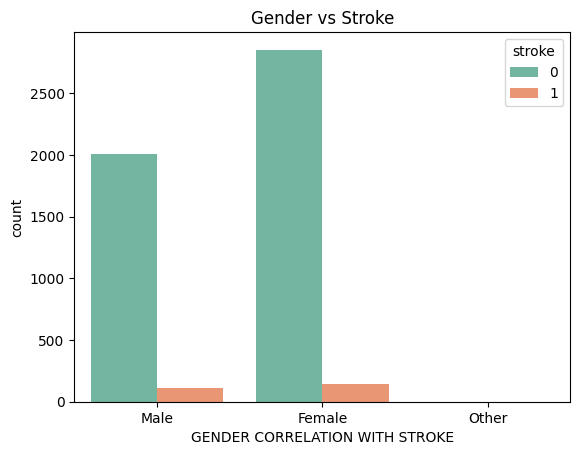

In [122]:
sns.countplot(data=df, x="gender", hue="stroke", palette="Set2")
plt.xlabel("GENDER CORRELATION WITH STROKE") 
plt.title("Gender vs Stroke")

Text(0.5, 1.0, 'MARRIED LEADS TO STROKE')

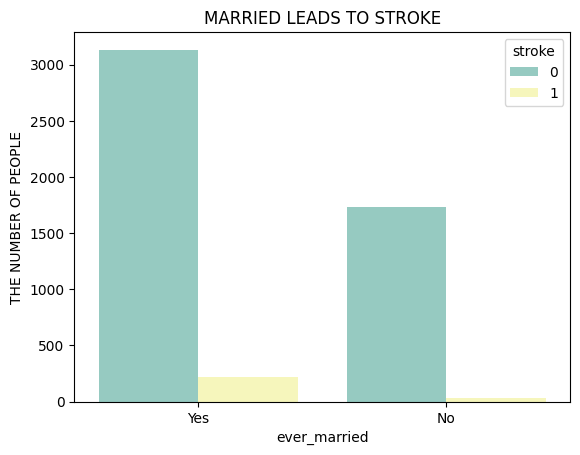

In [ ]:
sns.countplot(data=df, x="ever_married", hue="stroke", palette="Set2") 
plt.ylabel("THE NUMBER OF PEOPLE") 
plt.title("MARRIED LEADS TO STROKE")

 key correlations from our data sets are
* Age → Strongest positive correlation with stroke

* Hypertension → Moderate positive correlation

* Heart Disease → Moderate positive correlation

* Avg Glucose Level → Weak to moderate correlation

* BMI → Very weak correlation Higher average glucose levels are observed among stroke patients.


Major Insights

* Age is the strongest predictor of stroke.

* Patients with hypertension are significantly more likely to have stroke.

* Heart disease increases stroke risk. 

* Higher average glucose levels are observed among stroke patients.

* High glucose levels show moderate relationship.


Healthcare Recommendations

* Prioritize stroke screening for elderly patients.

* Monitor and manage hypertension aggressively.

* Control blood glucose levels in high-risk patients.

* Promote heart disease prevention programs.